## 1\. Data Profilling

### 1.1\. Dimensionality

In [1]:
import pandas as pd
from matplotlib.pyplot import figure, tight_layout, show
from dslabs_functions import *

file_tag = "TrafficTwoMonth"
filename = "datasets/TrafficTwoMonth_clean.csv"
target = "Total"
index = "datetime"

data: DataFrame = read_csv(
    filename,
    index_col=index,
    parse_dates=["datetime"],
)

series: Series = data[target]


<Figure size 600x450 with 0 Axes>

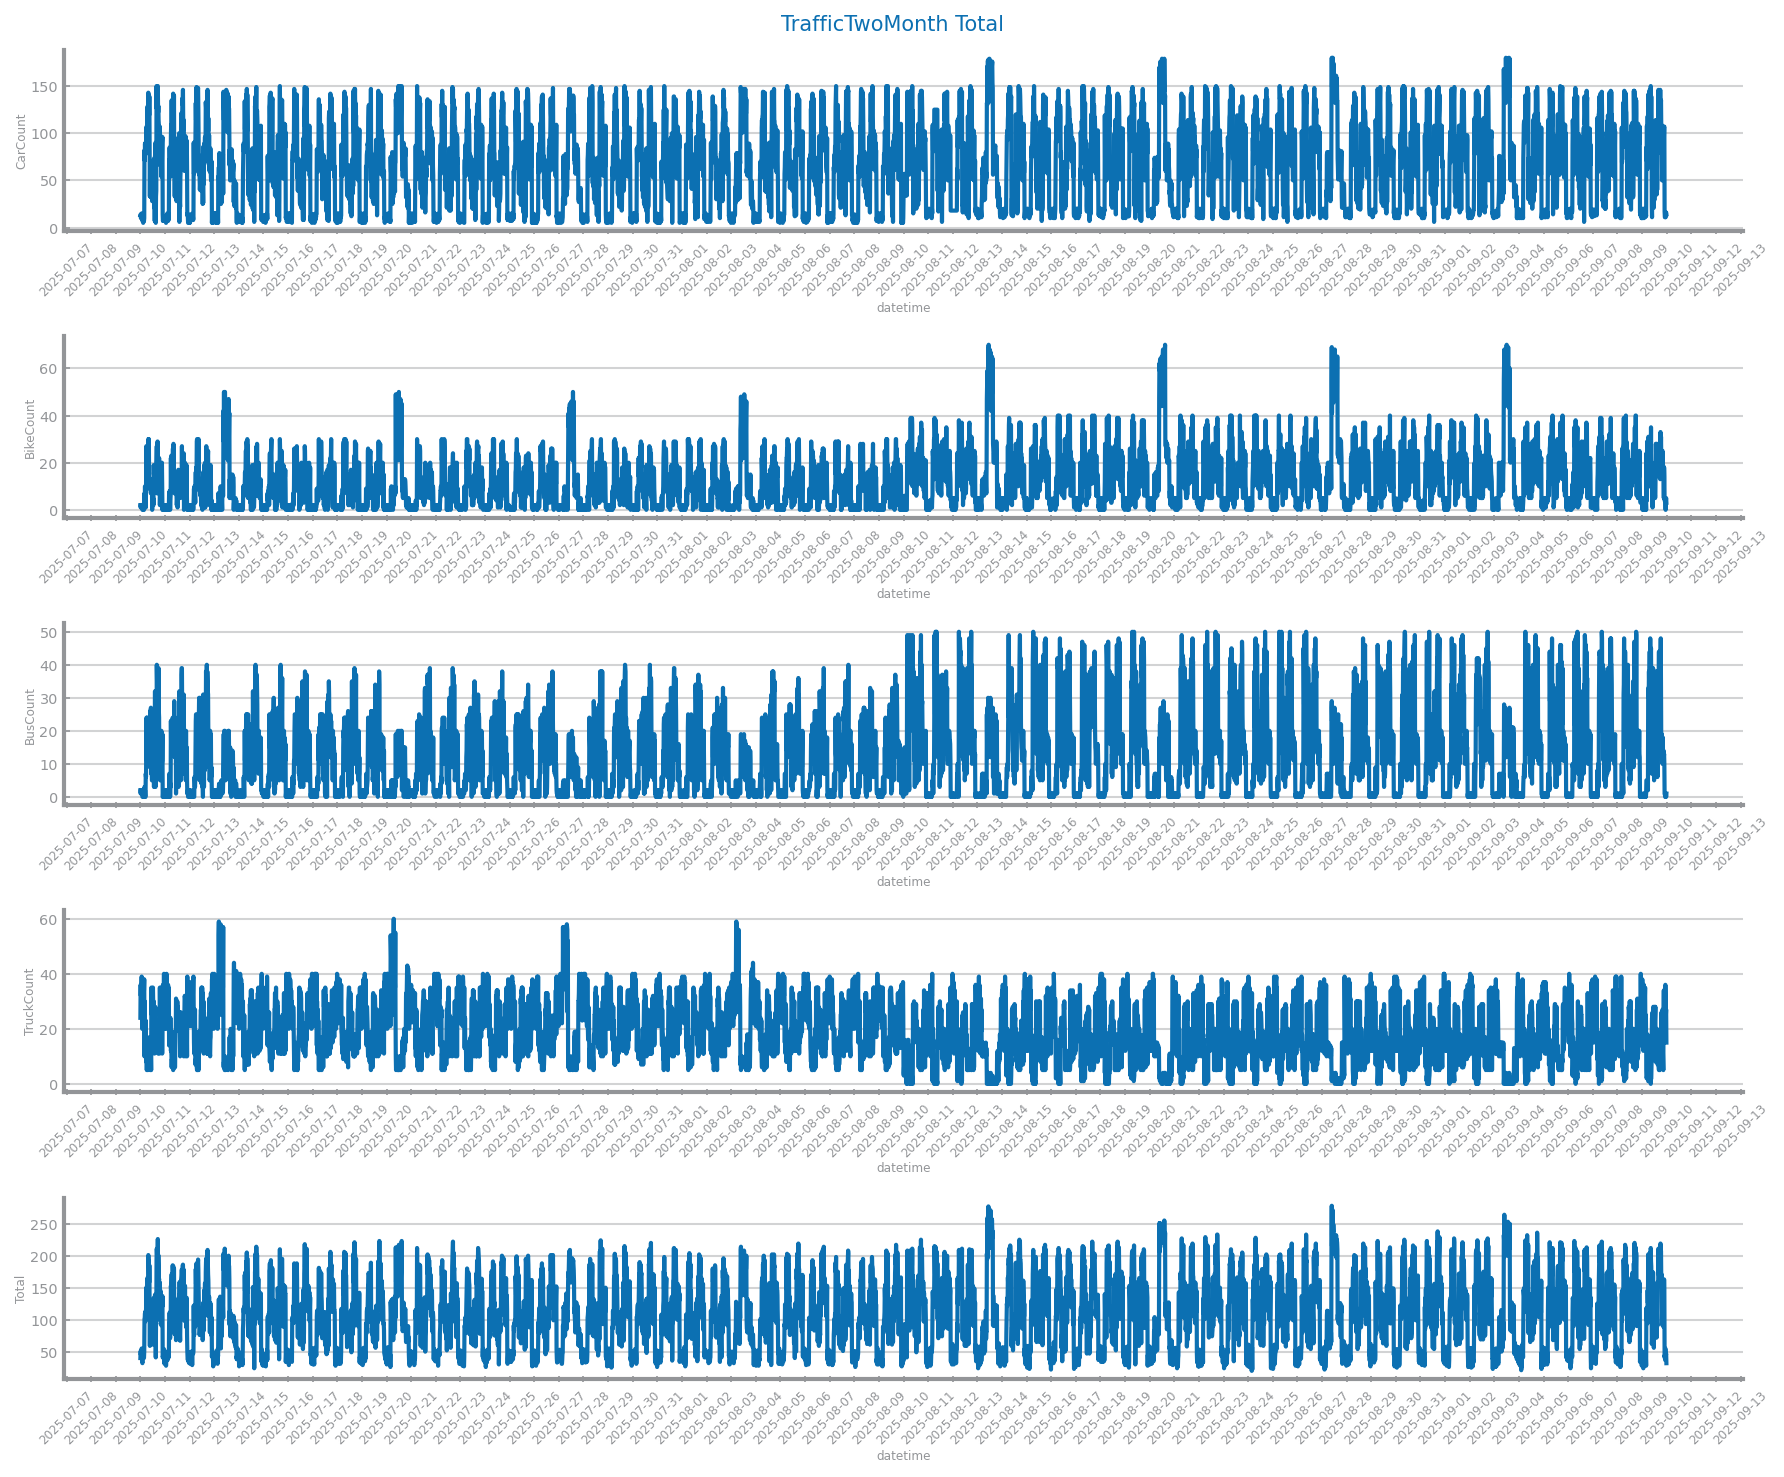

In [2]:
figure()
plot_ts_multivariate_chart(data, title=f"{file_tag} {target}")
tight_layout() 
show()

### 1.2\. Granularity

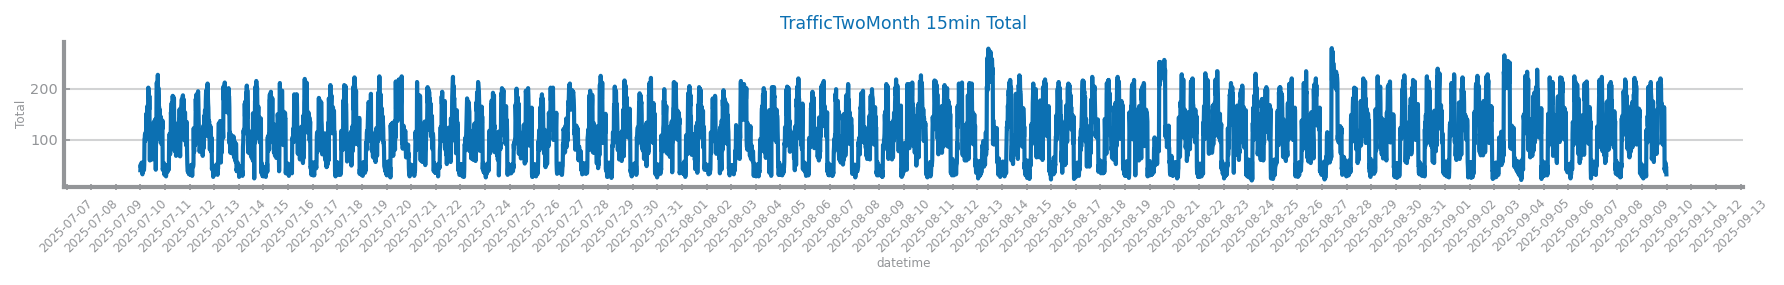

In [3]:
figure(figsize=(3 * HEIGHT, HEIGHT / 2))
plot_line_chart(
    series.index.to_list(),
    series.to_list(),
    xlabel=series.index.name,
    ylabel=target,
    title=f"{file_tag} 15min {target}",
)
tight_layout()
show()

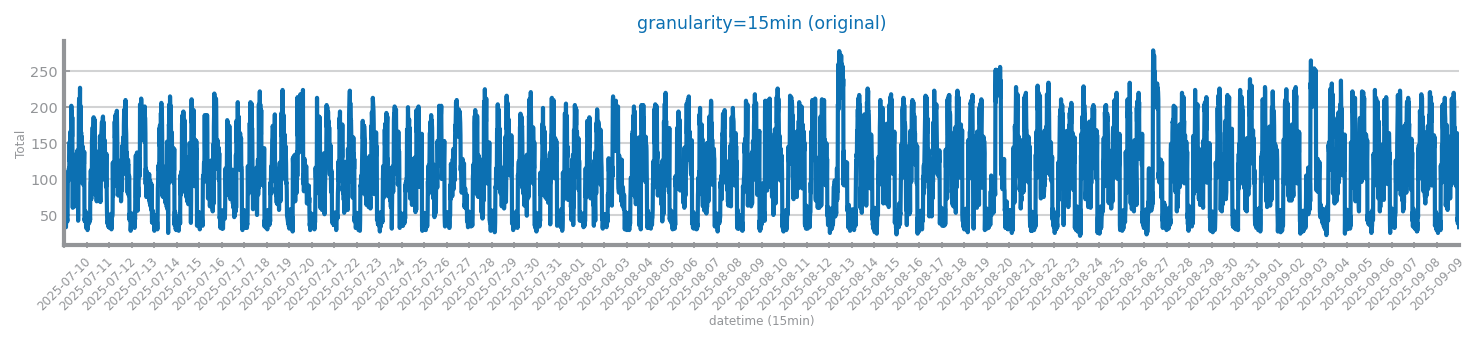

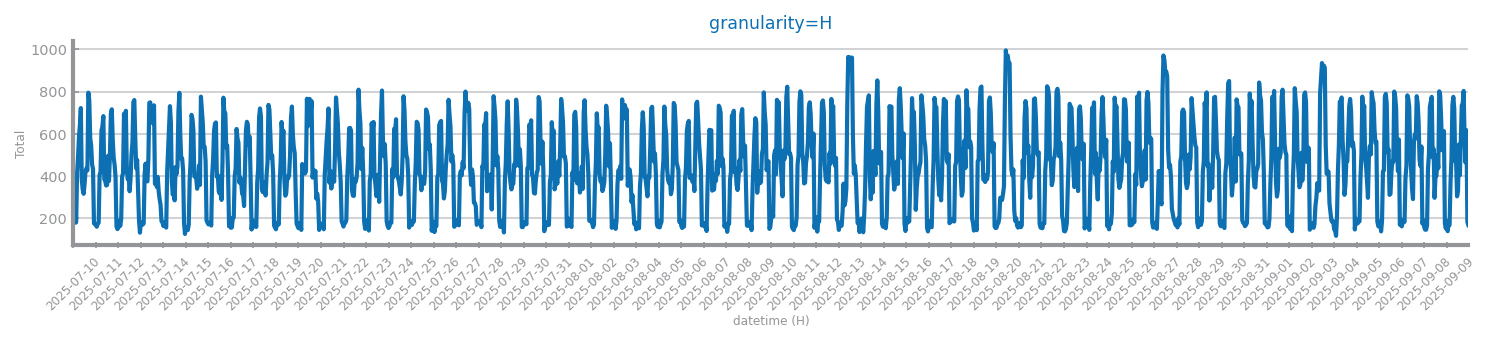

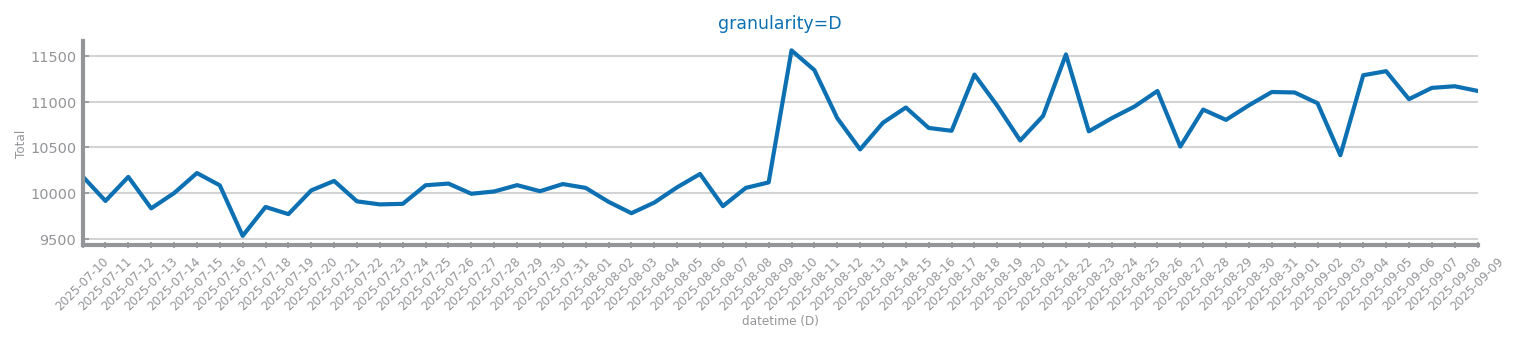

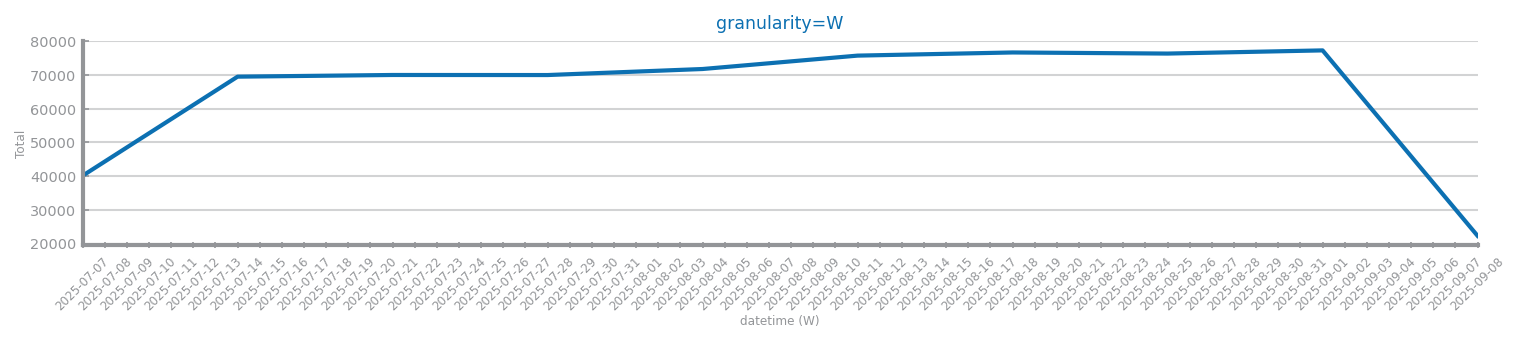

In [4]:
from matplotlib.pyplot import subplots
from matplotlib.axes import Axes
from matplotlib.figure import Figure

from matplotlib.pyplot import figure, gca, show

grans: list[str] = ["15min", "H", "D", "W"]

for gran in grans:
    ss: Series = ts_aggregation_by(series, gran, agg_func="sum")

    figure(figsize=(3 * HEIGHT, HEIGHT / 2))
    plot_line_chart(
        ss.index.to_list(),
        ss.to_list(),
        xlabel=f"{ss.index.name} ({gran})",
        ylabel=target,
        title=f"granularity={gran}" + (" (original)" if gran == "15min" else "")
    )

    # ---- FORCE X RANGE ----
    ax = gca()
    ax.set_xlim(ss.index.min(), ss.index.max())

show()




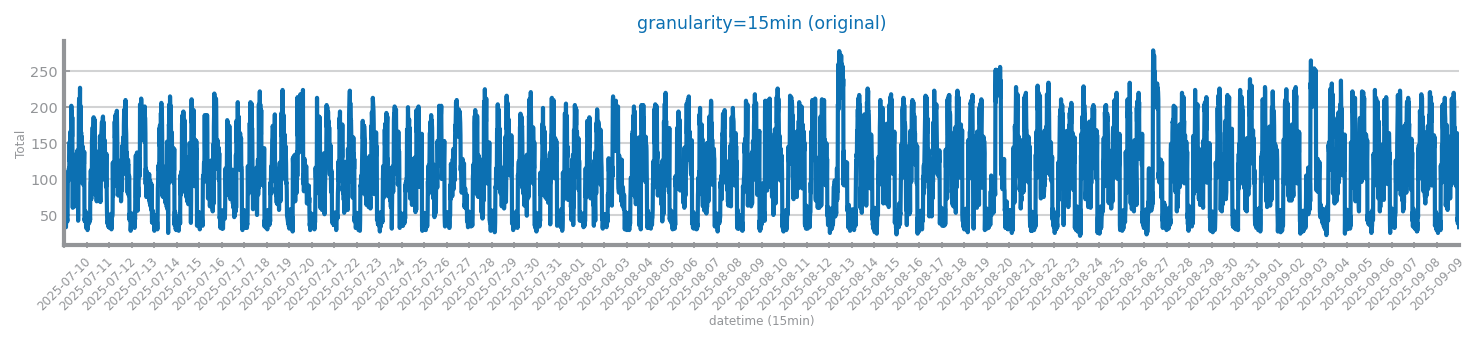

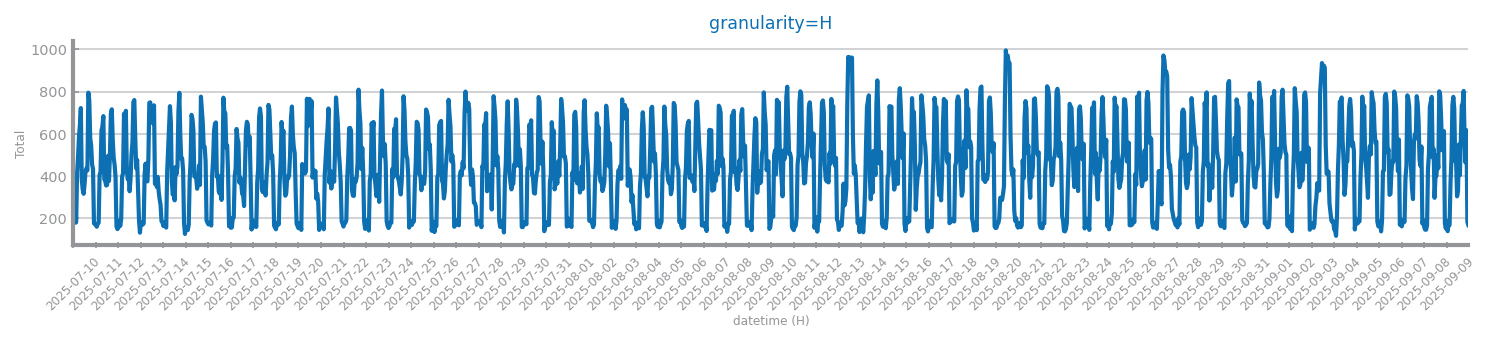

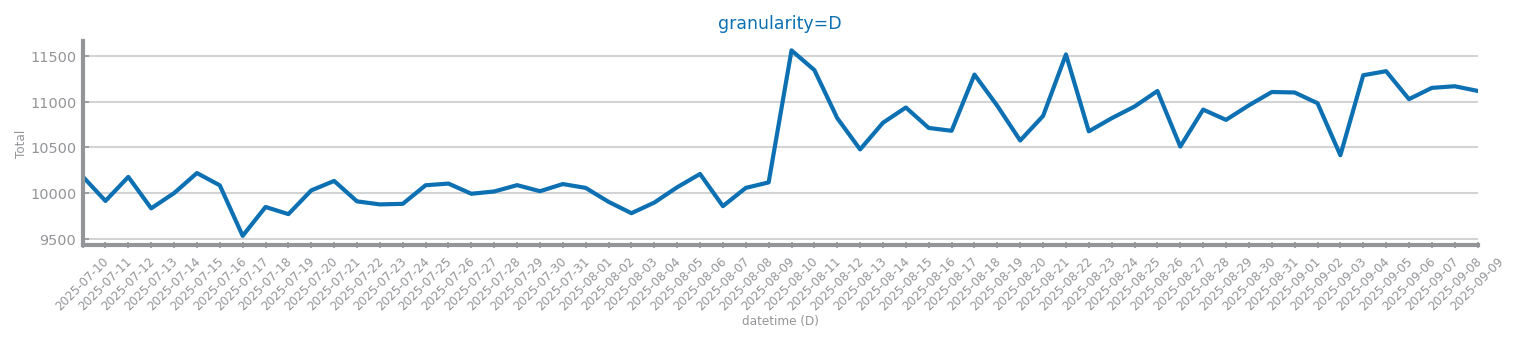

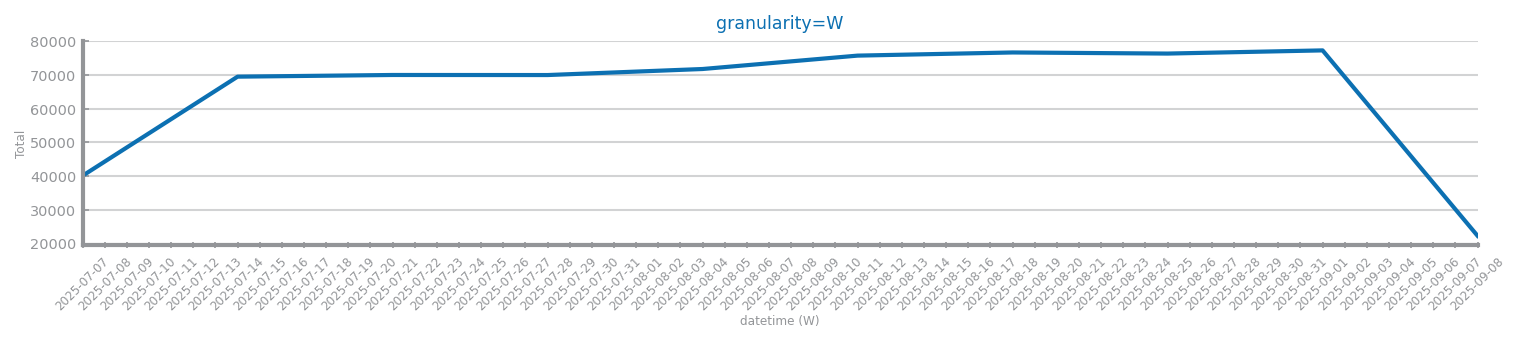

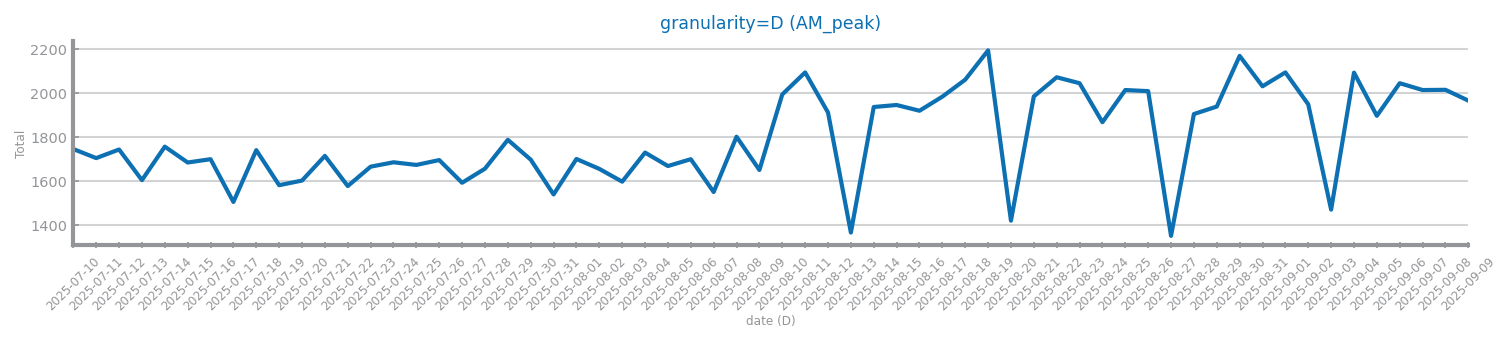

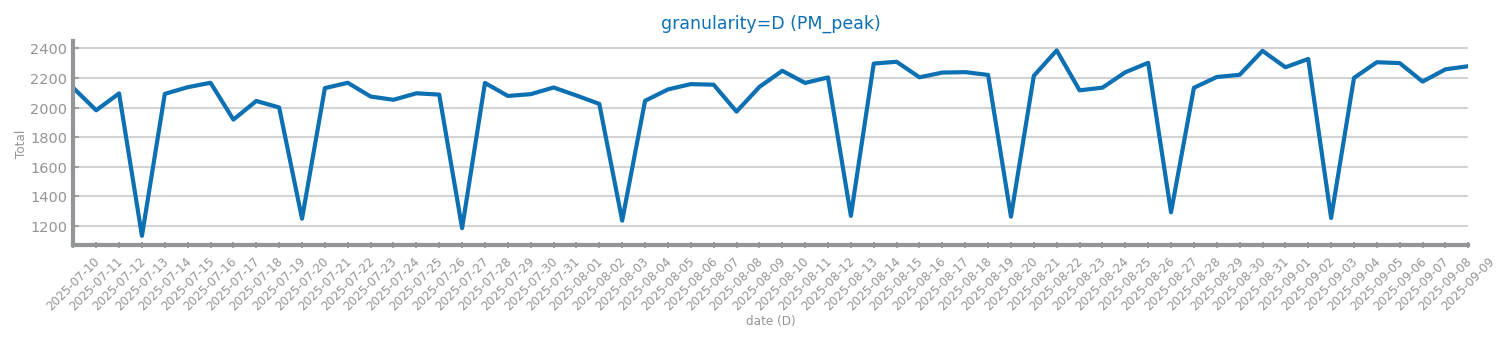

In [5]:
from matplotlib.pyplot import figure, gca, show

grans: list[str] = ["15min", "H", "D", "W"]

# ---- STANDARD GRANULARITIES ----
for gran in grans:
    ss = ts_aggregation_by(series, gran, agg_func="sum")

    figure(figsize=(3 * HEIGHT, HEIGHT / 2))
    plot_line_chart(
        ss.index.to_list(),
        ss.to_list(),
        xlabel=f"{ss.index.name} ({gran})",
        ylabel=target,
        title=f"granularity={gran}" + (" (original)" if gran == "15min" else "")
    )

    ax = gca()
    ax.set_xlim(ss.index.min(), ss.index.max())

# ---- PEAK PERIOD AGGREGATION ----
peak_periods = {
    "AM_peak": (7, 10),
    "PM_peak": (16, 19),
}

for name, (h_start, h_end) in peak_periods.items():
    peak_series = series[
        (series.index.hour >= h_start) &
        (series.index.hour < h_end)
    ]

    ss_peak = peak_series.resample("D").sum()

    figure(figsize=(3 * HEIGHT, HEIGHT / 2))
    plot_line_chart(
        ss_peak.index.to_list(),
        ss_peak.to_list(),
        xlabel="date (D)",
        ylabel=target,
        title=f"granularity=D ({name})"
    )

    ax = gca()
    ax.set_xlim(ss_peak.index.min(), ss_peak.index.max())

show()


### 1.3\. Distribution

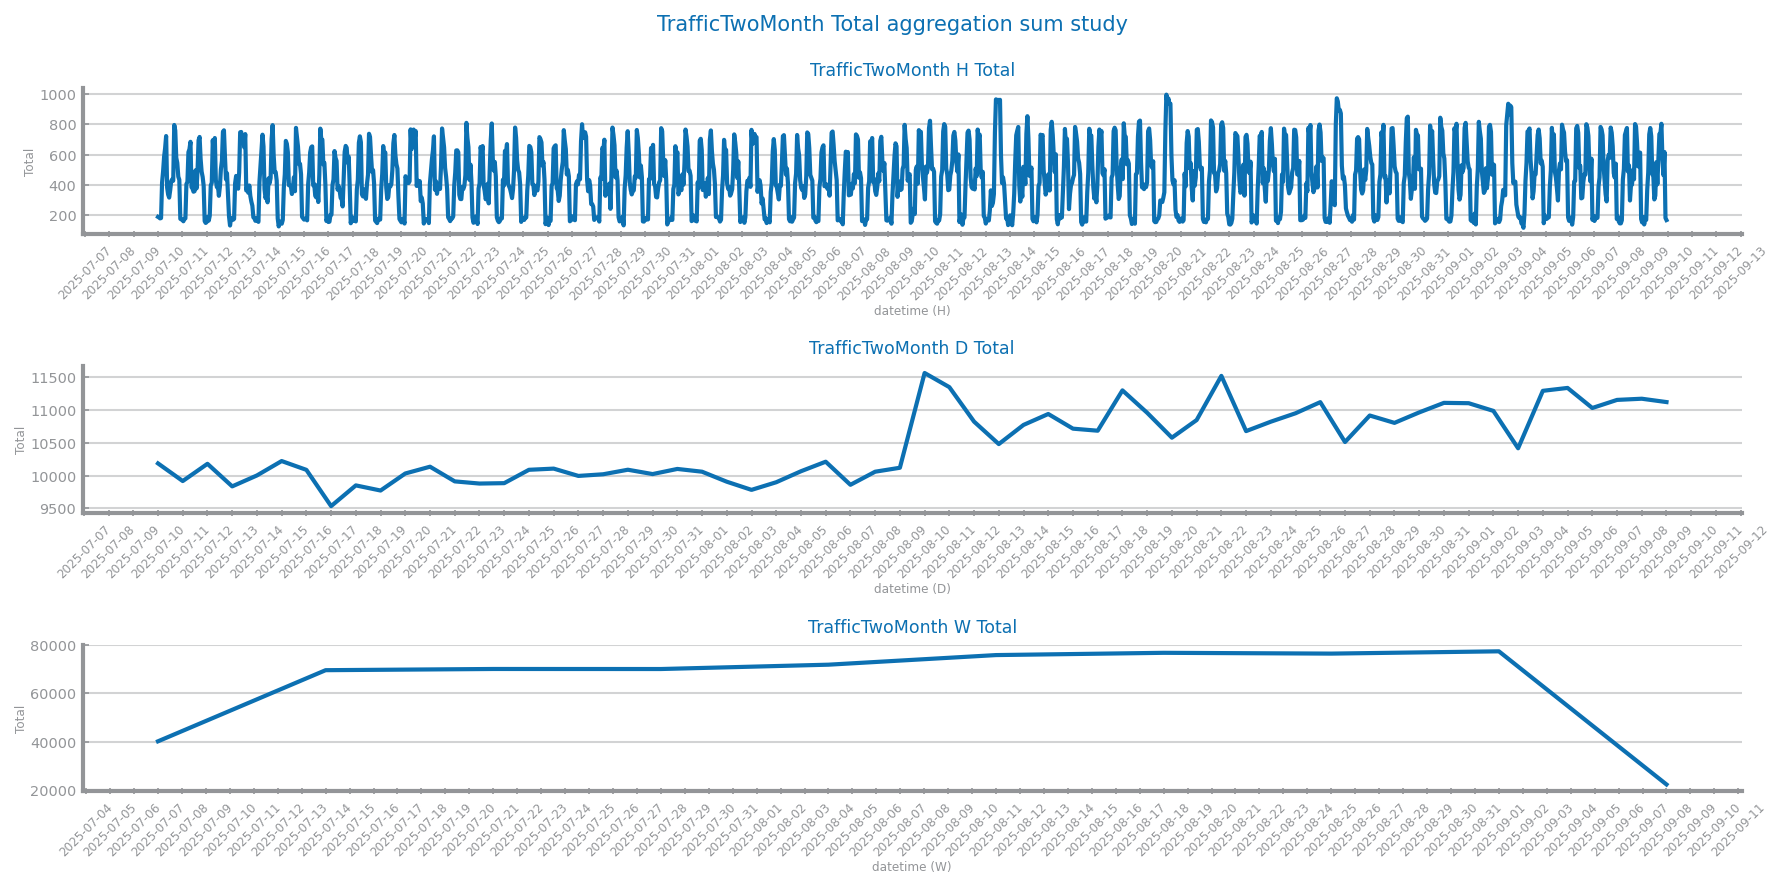

In [6]:
grans: list[str] = ["H", "D", "W"]
fig: Figure
axs: list[Axes]
fig, axs = subplots(len(grans), 1, figsize=(3 * HEIGHT, HEIGHT / 2 * len(grans)))
fig.suptitle(f"{file_tag} {target} aggregation sum study")

for i in range(len(grans)):
    ss: Series = ts_aggregation_by(series, grans[i], agg_func=sum)
    plot_line_chart(
        ss.index.to_list(),
        ss.to_list(),
        ax=axs[i],
        xlabel=f"{ss.index.name} ({grans[i]})",
        ylabel=target,
        title=f"{file_tag} {grans[i]} {target}",
    )
tight_layout()
show()

#### 1.3.1\. 5-Number Summary

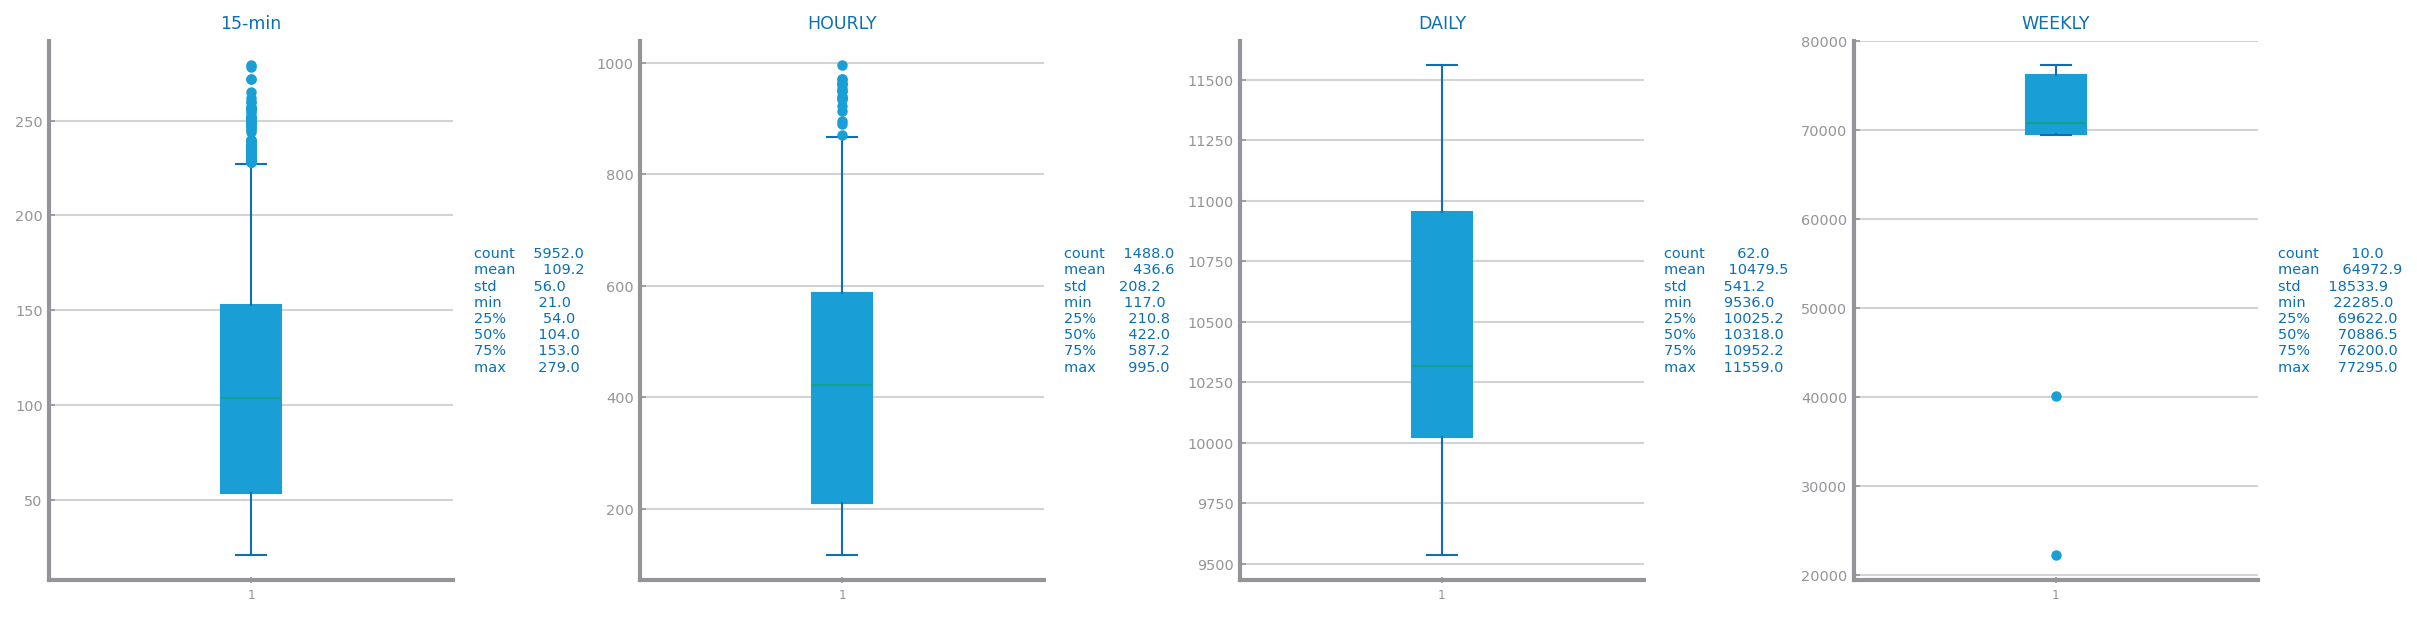

In [7]:
series: Series = data[target]

ss_original = ts_aggregation_by(series, gran_level="15min", agg_func=sum)
ss_hours    = ts_aggregation_by(series, gran_level="H",     agg_func=sum)
ss_days     = ts_aggregation_by(series, gran_level="D",     agg_func=sum)
ss_weeks    = ts_aggregation_by(series, gran_level="W",     agg_func=sum)
# ss_months  = ts_aggregation_by(series, gran_level="M",     agg_func=sum)

datasets = [
    ("15-min",   ss_original),
    ("HOURLY",   ss_hours),
    ("DAILY",    ss_days),
    ("WEEKLY",   ss_weeks)
    #("MONTHLY",  ss_months),
]

fig, axs = subplots(
    1, len(datasets),
    figsize=(len(datasets) * HEIGHT, HEIGHT),
    constrained_layout=True
)

# --- BOX PLOTS + STATS ---
for ax, (title, data_) in zip(axs, datasets):
    set_chart_labels(ax, title=title)
    ax.boxplot(data_)

    stats_str = data_.describe().round(1).to_string()
    ax.text(
        1.05, 0.5,
        stats_str,
        transform=ax.transAxes,
        fontsize="x-small",
        va="center",
        ha="left",
    )

show()



#### 1.3.2\. Variables Distribution

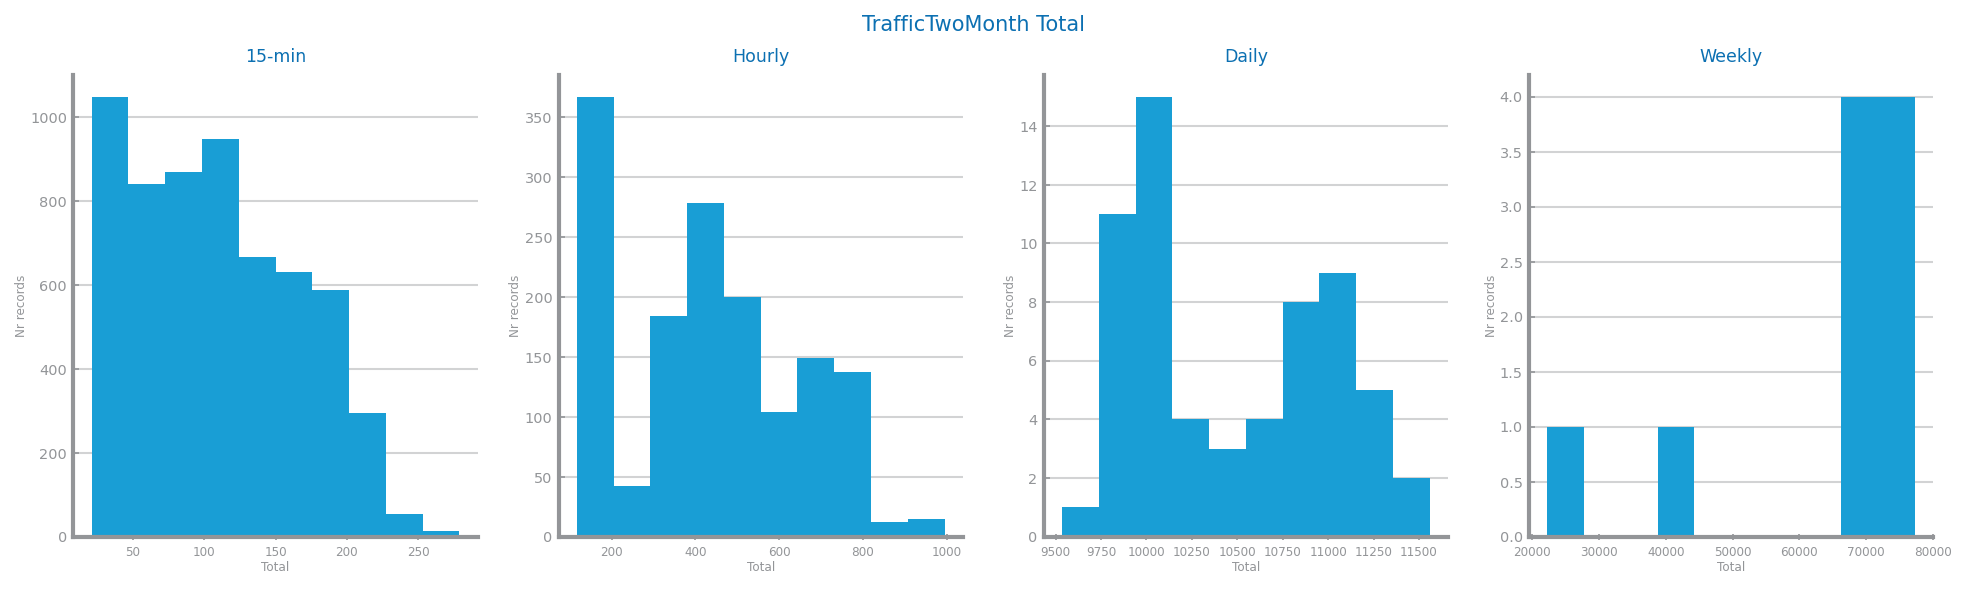

In [8]:
grans: list[Series] = [series, ss_hours, ss_days, ss_weeks]
gran_names: list[str] = ["15-min", "Hourly", "Daily", "Weekly"]
fig: Figure
axs: array
fig, axs = subplots(1, len(grans), figsize=(len(grans) * HEIGHT, HEIGHT))
fig.suptitle(f"{file_tag} {target}")
for i in range(len(grans)):
    set_chart_labels(axs[i], title=f"{gran_names[i]}", xlabel=target, ylabel="Nr records")
    axs[i].hist(grans[i].values)
show()

#### 1.3.3\. Autocorrelation
Lags allow to compare past values with current values.
A lag of 1 means you shift the series one position down — each entry is replaced with the value that occurred one time-step earlier. A lag of 2 means the value from two time-steps earlier, and so on

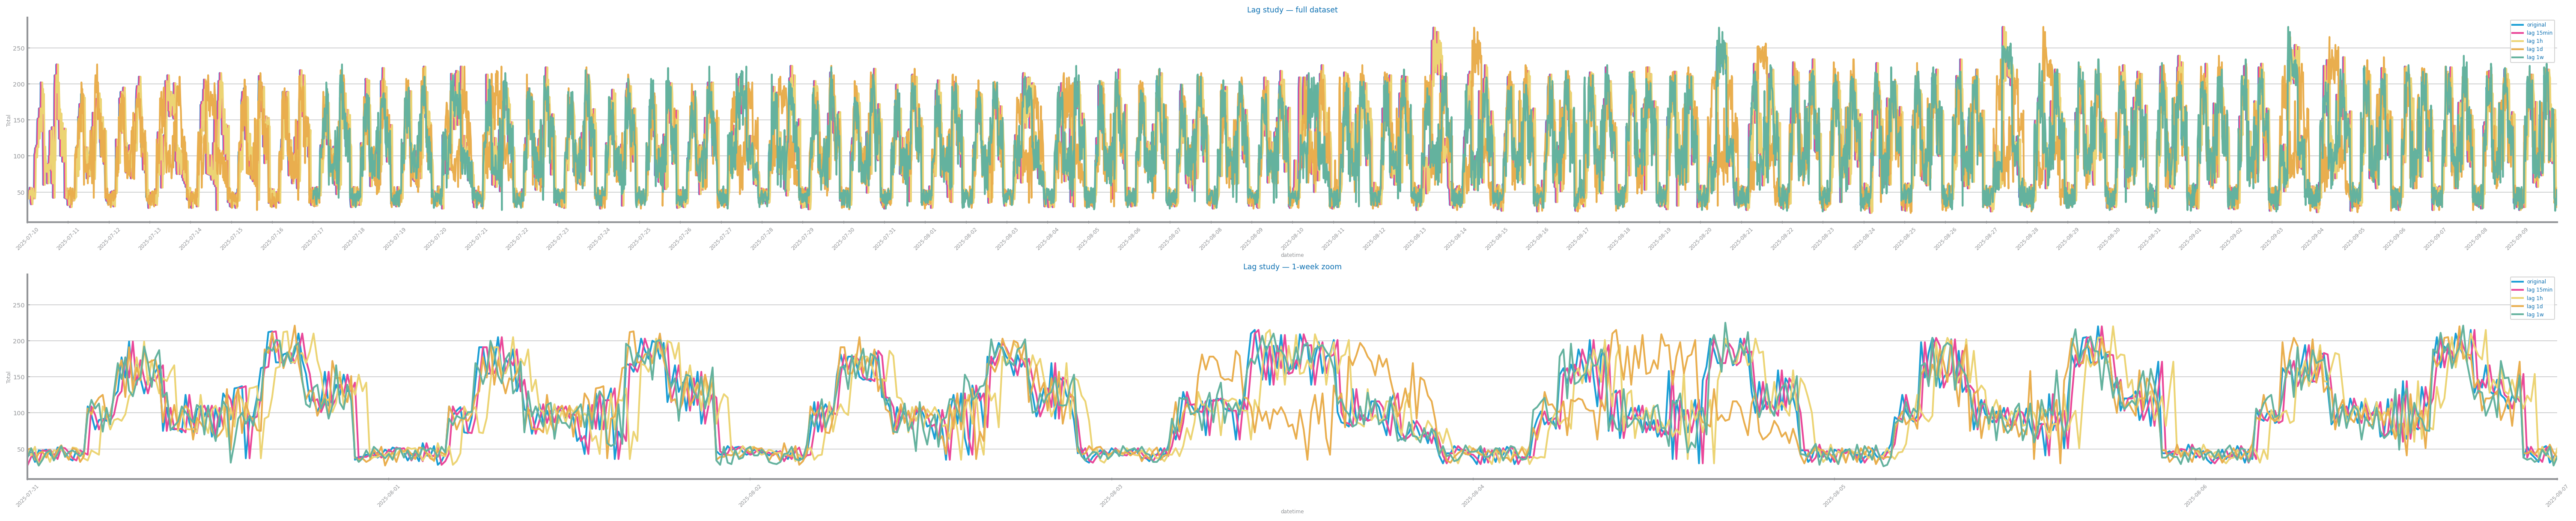

In [9]:
def get_lagged_series(
    series: Series,
    lags: list[int] | None = None,
    base_freq: str = "15min",
    include_original: bool = True,
) -> dict[str, Series]:
    
    s = series.copy()

    # Default lags for 15-min data: 15m, 1h, 1d, 1W
    if lags is None:
        lags = [1, 4, 96, 672]

    # Convert lag steps to a nice time label (based on base_freq)
    step = pd.Timedelta(base_freq)

    out: dict[str, Series] = {}
    if include_original:
        out["original"] = s

    for k in lags:
        td = k * step
        # Friendly label
        if td.components.days >= 7 and td.components.days % 7 == 0 and td.components.hours == 0 and td.components.minutes == 0:
            label = f"lag {td.components.days // 7}w"
        elif td.components.days >= 1 and td.components.hours == 0 and td.components.minutes == 0:
            label = f"lag {td.components.days}d"
        elif td.components.hours >= 1 and td.components.minutes == 0:
            label = f"lag {td.components.hours}h"
        else:
            minutes = int(td / pd.Timedelta(minutes=1))
            label = f"lag {minutes}min"

        out[label] = s.shift(k)

    return out

import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    2, 1,
    figsize=(10 * HEIGHT, 2 * HEIGHT),
    constrained_layout=True
)
lags = get_lagged_series(series)

# ---- FULL DATASET ----
plt.sca(axs[0])  # set current axis
plot_multiline_chart(series.index.to_list(), lags, xlabel=index, ylabel=target)
axs[0].set_xlim(pd.Timestamp("2025-07-10 00:00"), pd.Timestamp("2025-09-09 23:45:00"))
axs[0].set_title("Lag study — full dataset")

# ---- ONE-WEEK ZOOM ----
start = pd.Timestamp("2025-07-31 00:00")
end   = pd.Timestamp("2025-08-07 00:00")  # 1w zoom

plt.sca(axs[1])
plot_multiline_chart(series.index.to_list(), lags, xlabel=index, ylabel=target)

axs[1].set_xlim(start, end)
axs[1].set_title("Lag study — 1-week zoom")

plt.show()



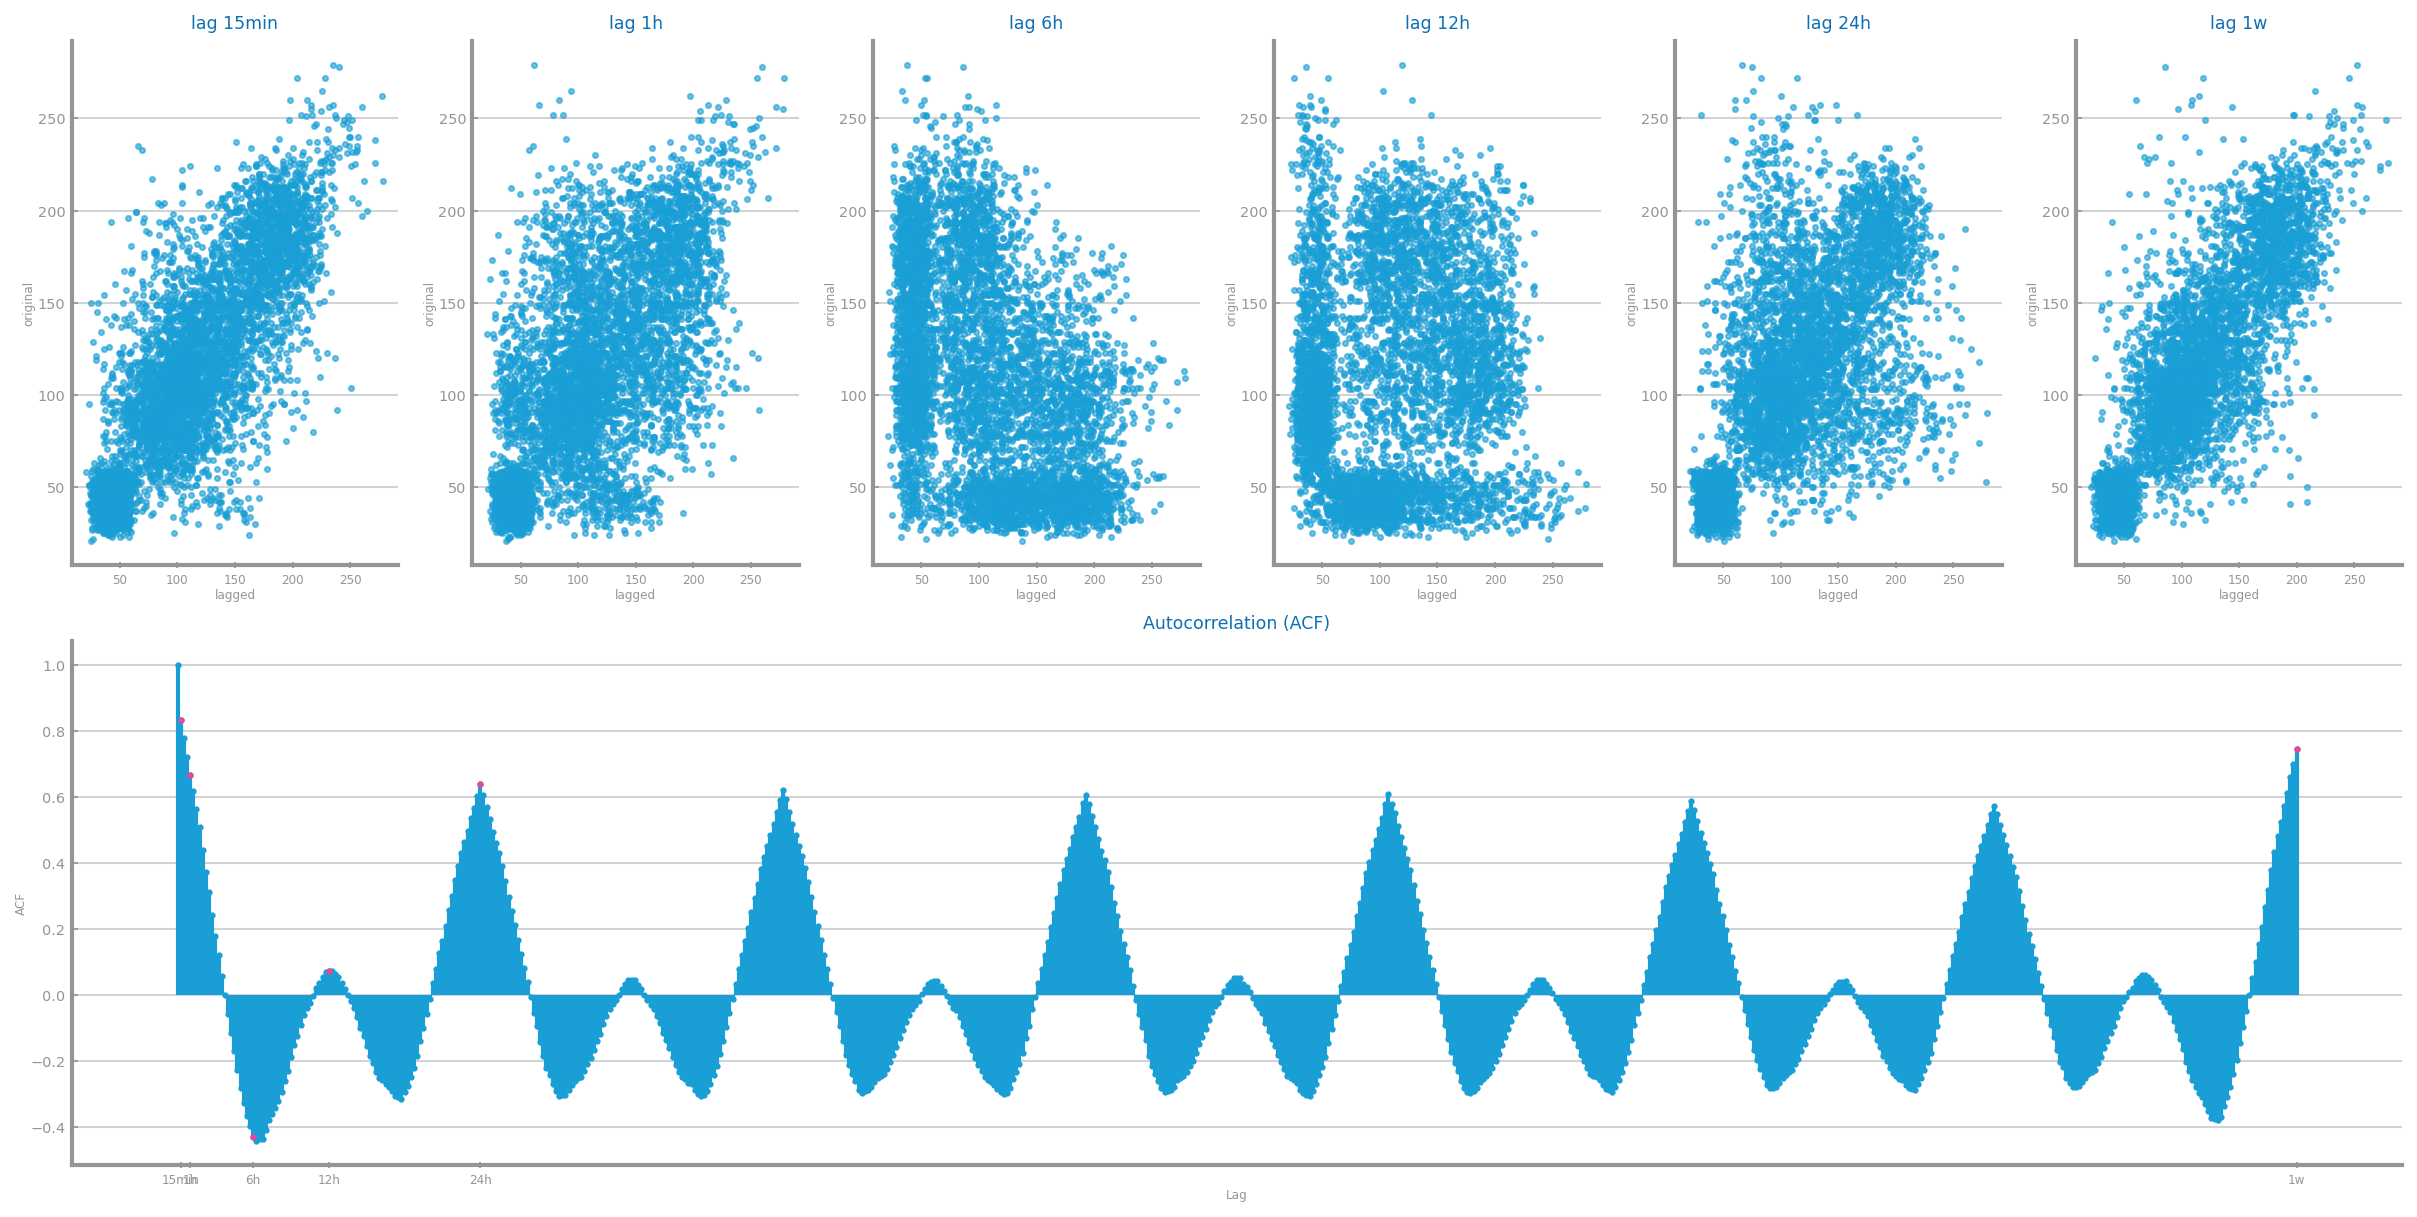

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pandas import Series
from statsmodels.tsa.stattools import acf


def autocorrelation_study(
    series: Series,
    base_freq: str = "15min",
):
    s = series.copy()
    step = pd.Timedelta(base_freq)

    # Your requested lags for 15-min data
    lag_steps = [1, 4, 24, 48, 96, 672]
    lag_labels = ["15min", "1h", "6h", "12h", "24h", "1w"]

    k = len(lag_steps)

    fig = plt.figure(figsize=(4 * HEIGHT, 2 * HEIGHT), constrained_layout=True)
    gs = GridSpec(2, k, figure=fig)

    # ---- SCATTER: original vs lagged ----
    for i, (steps, label) in enumerate(zip(lag_steps, lag_labels)):
        x = s.shift(steps)
        y = s
        valid = x.notna() & y.notna()

        ax = fig.add_subplot(gs[0, i])
        ax.scatter(x[valid].to_numpy(), y[valid].to_numpy(), s=6, alpha=0.6)
        ax.set_title(f"lag {label}")
        ax.set_xlabel("lagged")
        ax.set_ylabel("original")

    # ---- ACF PLOT (bottom row) ----
    ax = fig.add_subplot(gs[1, :])

    vals = s.dropna().to_numpy()
    max_lag = max(lag_steps)

    acf_vals = acf(vals, nlags=max_lag, fft=True)

    # full ACF
    ax.stem(range(len(acf_vals)), acf_vals, basefmt=" ")
    ax.set_title("Autocorrelation (ACF)")
    ax.set_ylabel("ACF")

    # set x ticks ONLY at the meaningful lags (same concept as scatters)
    ax.set_xticks(lag_steps)
    ax.set_xticklabels(lag_labels)
    ax.set_xlabel("Lag")

    # optional: emphasize the selected lags with markers
    ax.plot(lag_steps, [acf_vals[i] for i in lag_steps], "o")

    plt.show()

autocorrelation_study(series)


### 1.3\. Stationarity

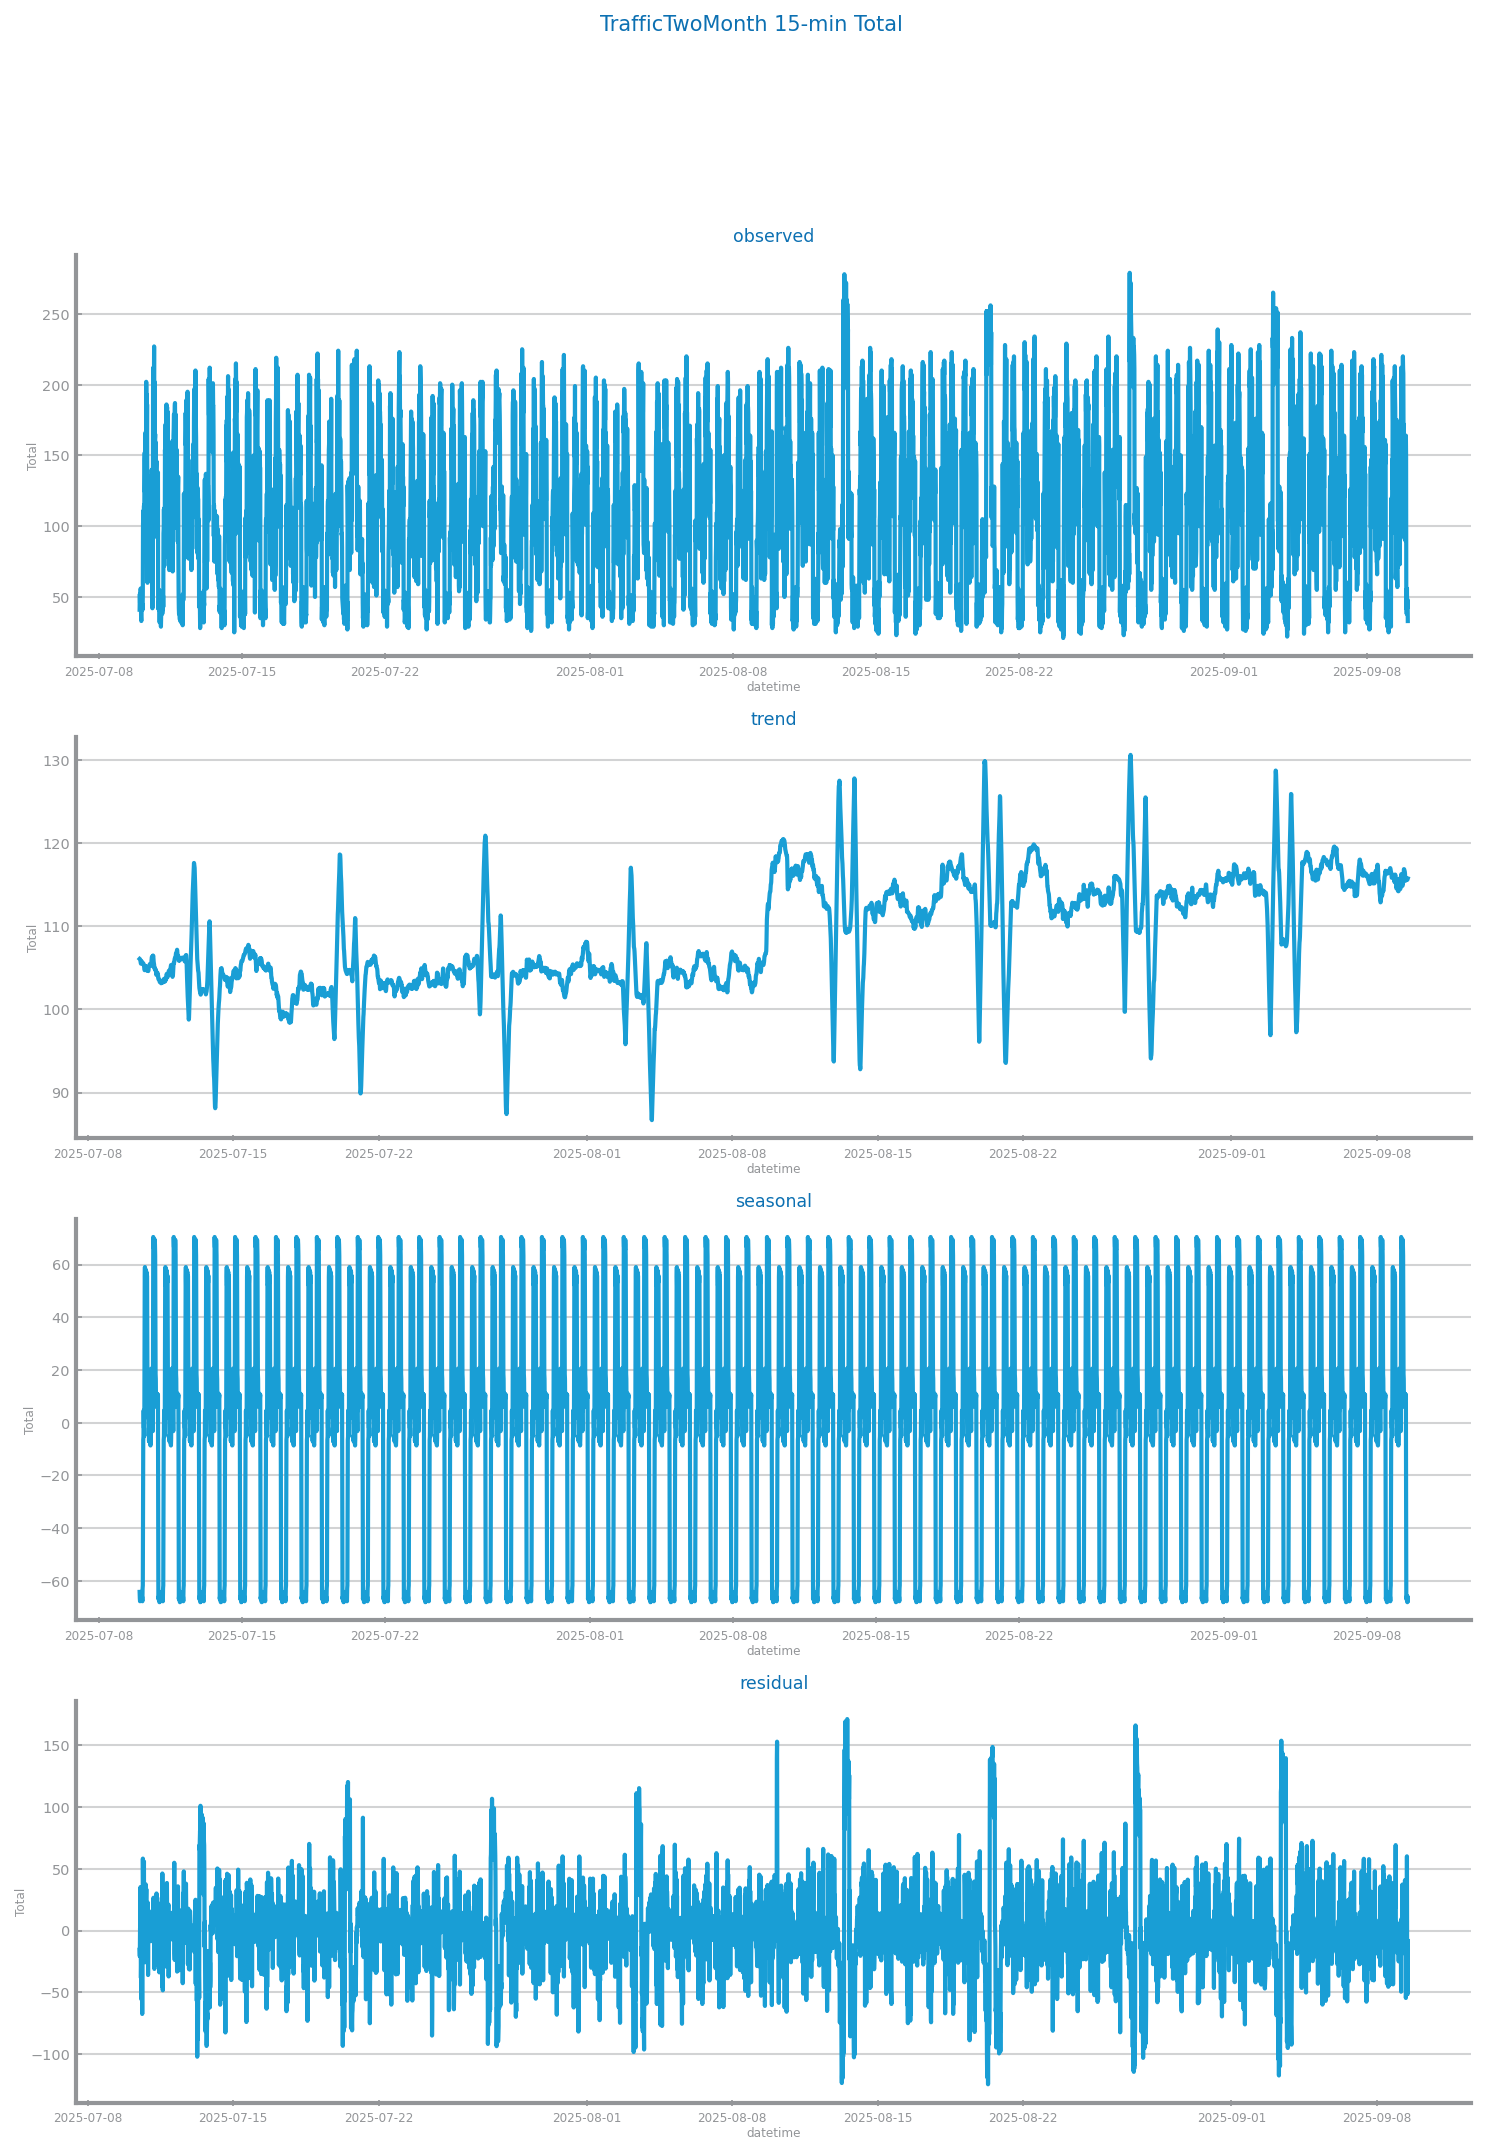

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose
from pandas import Series
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.pyplot import subplots
9, 
def plot_components(
    series: Series,
    title: str = "",
    x_label: str = "time",
    y_label: str = "",
    period: int = 96,          # <--- for 15-min data: 96 points per day
) -> list[Axes]:
    # ensure regular 15-min frequency
    series = series.asfreq("15T")

    decomposition = seasonal_decompose(
        series,
        model="add",
        period=period          # <--- key change
    )

    components: dict = {
        "observed": series,
        "trend": decomposition.trend,
        "seasonal": decomposition.seasonal,
        "residual": decomposition.resid,
    }

    rows: int = len(components)
    fig: Figure
    axs: list[Axes]
    fig, axs = subplots(rows, 1, figsize=(3 * HEIGHT, rows * HEIGHT))
    fig.suptitle(f"{title}")

    for i, key in enumerate(components):
        set_chart_labels(axs[i], title=key, xlabel=x_label, ylabel=y_label)
        axs[i].plot(components[key])

    return axs

plot_components(
    series,
    title=f"{file_tag} 15-min {target}",
    x_label=series.index.name,
    y_label=target,
)

show()


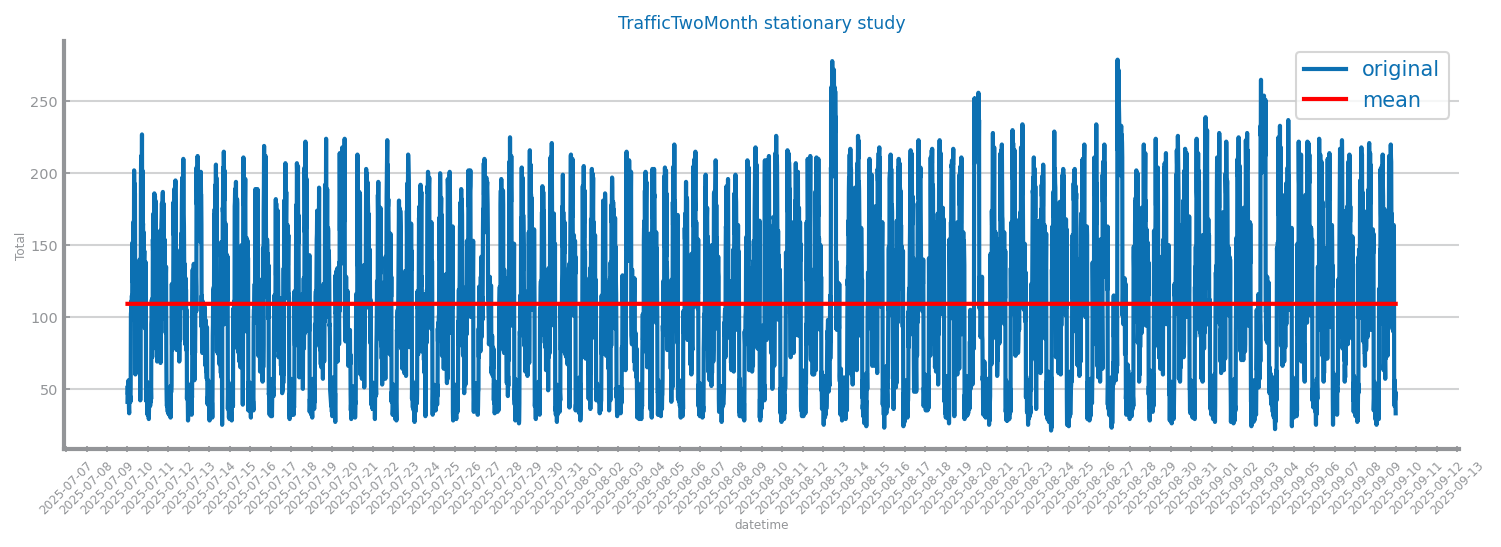

In [12]:
from matplotlib.pyplot import plot, legend

figure(figsize=(3 * HEIGHT, HEIGHT))
plot_line_chart(
    series.index.to_list(),
    series.to_list(),
    xlabel=series.index.name,
    ylabel=target,
    title=f"{file_tag} stationary study",
    name="original",
)
n: int = len(series)
plot(series.index, [series.mean()] * n, "r-", label="mean")
legend()
show()

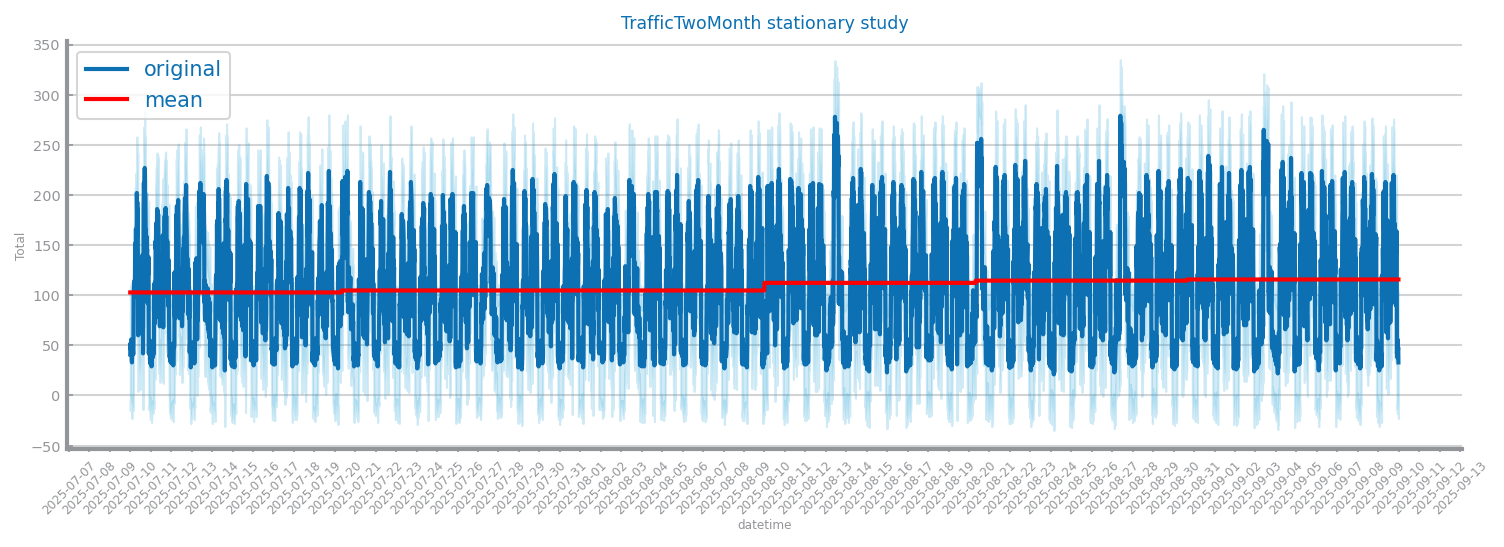

In [ ]:

BINS = 6
mean_line: list[float] = []

for i in range(BINS):
    segment: Series = series[i * n // BINS : (i + 1) * n // BINS]
    mean_value: list[float] = [segment.mean()] * (n // BINS)
    mean_line += mean_value
mean_line += [mean_line[-1]] * (n - len(mean_line))

figure(figsize=(3 * HEIGHT, HEIGHT))
plot_line_chart(
    series.index.to_list(),
    series.to_list(),
    xlabel=series.index.name,
    ylabel=target,
    title=f"{file_tag} stationary study",
    name="original",
    show_stdev=True,
)
n: int = len(series)
plot(series.index, mean_line, "r-", label="mean")
legend()
show()

#### 1.3.3\. Augmented Dickey-Fuller test
The **Augmented Dickey-Fuller test** is a statistical test widely used to verify the stationarity of a series. It determines how strongly a time series is defined by a trend: if this is true, then the series is non-stationary.
In this manner, we have two cases:
- **p-value <= 0.05** : the series is stationary, meaning its values do not depend on time;
- **p-value > 0.05** : the series is non-stationary, meaning it shows a time-dependent structure.


In [14]:
from statsmodels.tsa.stattools import adfuller

def eval_stationarity(series: Series) -> bool:
    result = adfuller(series)
    print(f"ADF Statistic: {result[0]:.3f}")
    print(f"p-value: {result[1]:.3f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"\t{key}: {value:.3f}")
    return result[1] <= 0.05


print(f"The series {('is' if eval_stationarity(series) else 'is not')} stationary")

ADF Statistic: -14.441
p-value: 0.000
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567
The series is stationary
